# Stage 2  Unified Multimodal Alignment

This notebook walks through Stage 2 of **Unified-DTI**:  
bridging structure (512-dim) and image (512-dim) embeddings from Stage 1 into a unified space via multi-positive InfoNCE loss.

Drug-target pairs sharing the same interaction ID are treated as positives.

All model code lives in `src/stage2/model/`. This notebook imports from those files directly.

## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src', 'stage2', 'model'))

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import CONFIG
from dataset import StructureImageDataset
from model import ContrastiveModel
from loss import MultiPositiveInfoNCELoss, compute_alignment_metrics
from train import train_epoch, validate

## Configuration

In [ ]:
BASE = os.path.join('..', 'src', 'stage2')

CONFIG['train_csv'] = os.path.join(BASE, 'data', 'train_pairs.csv')
CONFIG['test_csv'] = os.path.join(BASE, 'data', 'test_pairs.csv')
CONFIG['drug_struct_path'] = os.path.join(BASE, 'embedding', 'contrastive_new_smile_embeddings.pt')
CONFIG['drug_img_path'] = os.path.join(BASE, 'embedding', 'contrastive_new_img_drug_embeddings.pt')
CONFIG['prot_struct_path'] = os.path.join(BASE, 'embedding', 'contrastive_new_protein_embeddings.pt')
CONFIG['prot_img_path'] = os.path.join(BASE, 'embedding', 'contrastive_new_img_protein_embeddings.pt')
CONFIG['save_dir'] = os.path.join(BASE, 'model')

## Dataset

Stage 2 requires four 512-dim projected embedding files produced by `src/stage2/embedding/generate_embeddings.py`.  
Download from OneDrive and place in `src/stage2/embedding/`.

In [3]:
train_dataset = StructureImageDataset(
    CONFIG['train_csv'],
    CONFIG['drug_struct_path'],
    CONFIG['drug_img_path'],
    CONFIG['prot_struct_path'],
    CONFIG['prot_img_path']
)

test_dataset = StructureImageDataset(
    CONFIG['test_csv'],
    CONFIG['drug_struct_path'],
    CONFIG['drug_img_path'],
    CONFIG['prot_struct_path'],
    CONFIG['prot_img_path']
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

Encoded 15292 unique pair IDs.
Encoded 5746 unique pair IDs.


## Training

In [4]:
device = CONFIG['device']

model     = ContrastiveModel(CONFIG['input_dim'], CONFIG['hidden_dim'], CONFIG['output_dim'], CONFIG['dropout']).to(device)
criterion = MultiPositiveInfoNCELoss(temperature=CONFIG['temperature'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'])

best_val_loss = float('inf')

for epoch in range(CONFIG['num_epochs']):

    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")

    train_loss, train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_metrics   = validate(model, val_loader, criterion, device)
    scheduler.step()

    if epoch % 10 == 0:
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train Metrics - Pos Sim: {train_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {train_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {train_metrics['gap']:.4f}, ")
        print(f"Val Metrics   - Pos Sim: {val_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {val_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {val_metrics['gap']:.4f}, ")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(CONFIG['save_dir'], 'best_model.pt'))

print(f"\nDone. Best val loss: {best_val_loss:.4f}")


Epoch 1/30


/ix1/ychiu/yil346/DTI_v3/Github_testing/src/stage2/model/train.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['id'], dtype=torch.long).to(device)
Training: 100%|██████████| 239/239 [00:03<00:00, 77.52it/s]
/ix1/ychiu/yil346/DTI_v3/Github_testing/src/stage2/model/train.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['id'], dtype=torch.long).to(device)
Validating: 100%|██████████| 90/90 [00:00<00:00, 121.45it/s]


Train Loss: 4.4714, Val Loss: 3.6336
Train Metrics - Pos Sim: 0.1674, Neg Sim: 0.0043, Gap: 0.1631, 
Val Metrics   - Pos Sim: 0.3856, Neg Sim: 0.0094, Gap: 0.3762, 

Epoch 2/30


Validating: 100%|██████████| 90/90 [00:00<00:00, 122.06it/s]



Epoch 3/30


...


Epoch 29/30


Validating: 100%|██████████| 90/90 [00:00<00:00, 122.15it/s]



Epoch 30/30


Validating: 100%|██████████| 90/90 [00:00<00:00, 122.82it/s]


Done. Best val loss: 3.0104


## Inference

Load the best checkpoint and project all four modalities into the unified space.  
Saves a `unified_embeddings.pt` with keys: `drug_structure`, `drug_image`, `target_structure`, `target_image`.

In [5]:
device = 'cpu'

model = ContrastiveModel(input_dim=512, hidden_dim=1024, output_dim=512, dropout=0.1)
model.load_state_dict(torch.load(os.path.join(CONFIG['save_dir'], 'best_model.pt'), map_location=device))
model.to(device)
model.eval()

/scratch/slurm-2447629/ipykernel_1055002/2085168999.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CONFIG['save_dir'], 'be

ContrastiveModel(
  (struct_projector): ProjectionHead(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=1024, out_features=512, bias=True)
      (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (img_projector): ProjectionHead(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=1024, out_features=512, bias=True)
      (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_ru

In [6]:
drug_structure_dict  = torch.load(CONFIG['drug_struct_path'], weights_only=True)
drug_image_dict = torch.load(CONFIG['drug_img_path'], weights_only=True)
protein_structure_dict = torch.load(CONFIG['prot_struct_path'], weights_only=True)
protein_image_dict = torch.load(CONFIG['prot_img_path'], weights_only=True)

In [7]:
embeddings = {'drug_structure': {}, 'drug_image': {}, 'target_structure': {}, 'target_image': {}}

with torch.no_grad():
    for batch in val_loader:
        struct_embeds = batch['structure'].to(device)
        img_embeds = batch['image'].to(device)
        struct_keys = batch['structure_key']
        img_keys = batch['image_key']

        struct_features, img_features = model(struct_embeds, img_embeds)
        struct_features = struct_features.cpu()
        img_features = img_features.cpu()

        for s_key, i_key, s_vec, i_vec in zip(struct_keys, img_keys, struct_features, img_features):
            if s_key in drug_structure_dict:
                embeddings['drug_structure'][s_key] = s_vec
            elif s_key in protein_structure_dict:
                embeddings['target_structure'][s_key] = s_vec

            if i_key in drug_image_dict:
                embeddings['drug_image'][i_key] = i_vec
            elif i_key in protein_image_dict:
                embeddings['target_image'][i_key] = i_vec

for k, v in embeddings.items():
    print(f"{k}: {len(v)} entries")

torch.save(embeddings, os.path.join(CONFIG['save_dir'], 'unified_embeddings.pt'))
print("Saved to unified_embeddings.pt")

drug_structure: 789 entries
drug_image: 789 entries
target_structure: 1065 entries
target_image: 1065 entries
Saved to unified_embeddings.pt


## Visualization

Cosine similarity distribution across the full validation set using multi-positive masking.

In [8]:
def collect_val_similarities(model, dataloader, device):
    model.eval()
    all_pos_sim, all_neg_sim = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Collecting similarities"):
            struct_embeds = batch['structure'].to(device)
            img_embeds = batch['image'].to(device)
            labels = torch.tensor(batch['id'], dtype=torch.long).to(device)

            struct_proj, img_proj = model(struct_embeds, img_embeds)
            sim_matrix = torch.matmul(struct_proj, img_proj.T)

            labels = labels.view(-1, 1)
            pos_mask = torch.eq(labels, labels.T)
            neg_mask = ~pos_mask

            pos_sim = sim_matrix[pos_mask]
            neg_sim = sim_matrix[neg_mask]

            if len(pos_sim) > 0: all_pos_sim.append(pos_sim.cpu())
            if len(neg_sim) > 0: all_neg_sim.append(neg_sim.cpu())

    return torch.cat(all_pos_sim), torch.cat(all_neg_sim)


val_pos_sim, val_neg_sim = collect_val_similarities(model, val_loader, device)
print("Positive mean:", val_pos_sim.mean().item())
print("Negative mean:", val_neg_sim.mean().item())

/scratch/slurm-2447629/ipykernel_1055002/3210466531.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['id'], dtype=torch.long).to(device)

Positive mean: 0.6223738789558411
Negative mean: 0.009311432018876076


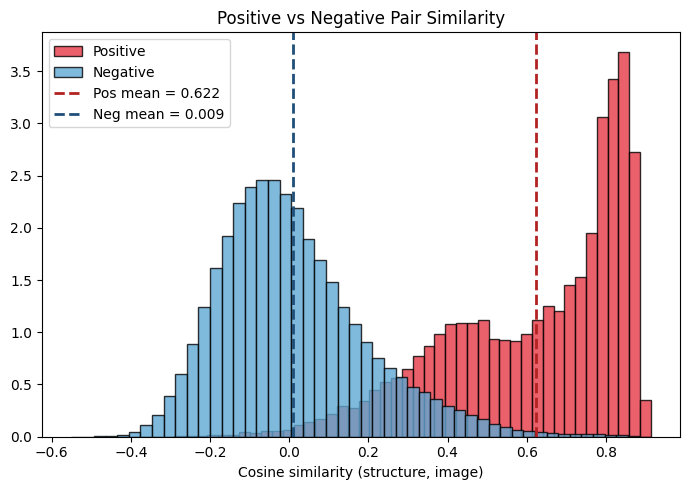

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.hist(val_pos_sim, bins=50, color='#e63946', alpha=0.8, label='Positive', density=True, edgecolor='black')
plt.hist(val_neg_sim, bins=50, color='#5fa8d3', alpha=0.8, label='Negative', density=True, edgecolor='black')
plt.axvline(val_pos_sim.mean(), color='#b22222', linestyle='--', linewidth=2, label=f'Pos mean = {val_pos_sim.mean():.3f}')
plt.axvline(val_neg_sim.mean(), color='#1f4e79', linestyle='--', linewidth=2, label=f'Neg mean = {val_neg_sim.mean():.3f}')
plt.xlabel('Cosine similarity (structure, image)')
plt.title('Positive vs Negative Pair Similarity')
plt.legend()
plt.tight_layout()
plt.show()